In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('chapter_data.csv')

# Convert chapter column from text to numbers
# 'coerce' turns any text that isn't a number into NaN
df['chapter'] = pd.to_numeric(df['chapter'], errors='coerce')

# Convert date column into a proper Datetime object
df['date'] = pd.to_datetime(df['date'])

# Drop any rows where chapter became NaN
df = df.dropna(subset='chapter')

# Keep only rows where chapter number is greater than 0
df = df[df['chapter'] > 0]

In [16]:
# Get integers representing days since first release
df['Days since first release'] = (df['date'] - df['date'].min()).dt.days
df['Days since first release']

0           0
1           7
2          14
3          21
4          35
        ...  
1171    10409
1172    10423
1173    10430
1174    10437
1175    10451
Name: Days since first release, Length: 1175, dtype: int64

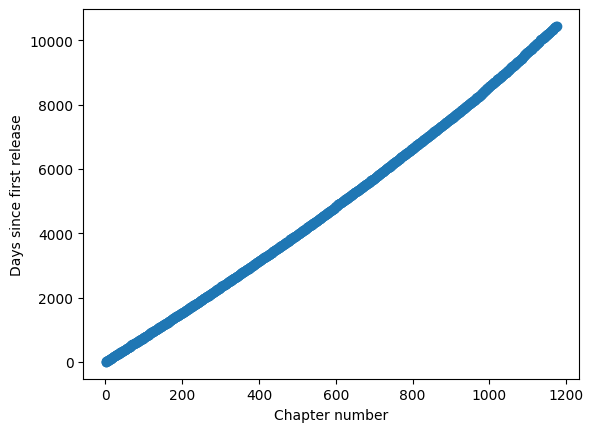

In [17]:
plt.figure()
plt.scatter(df['chapter'], df['Days since first release'])
plt.xlabel('Chapter number')
plt.ylabel('Days since first release')
plt.show()

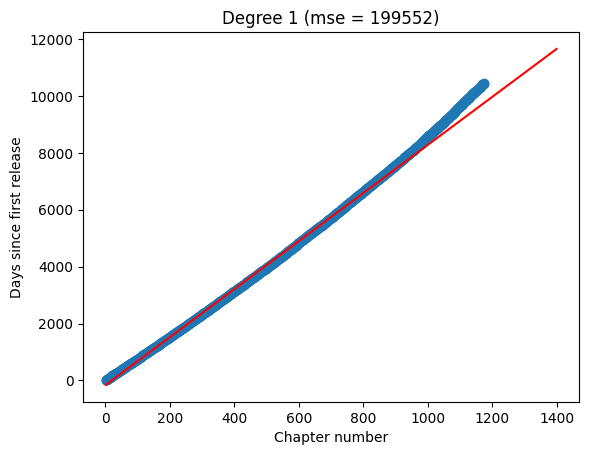

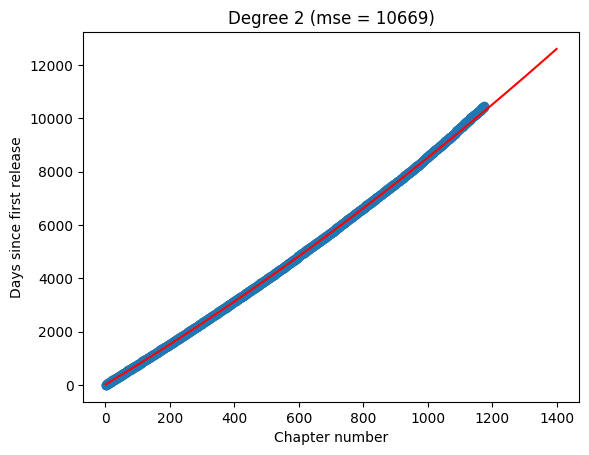

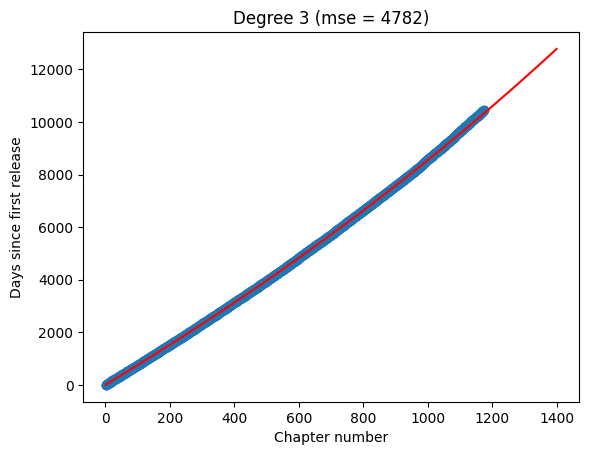

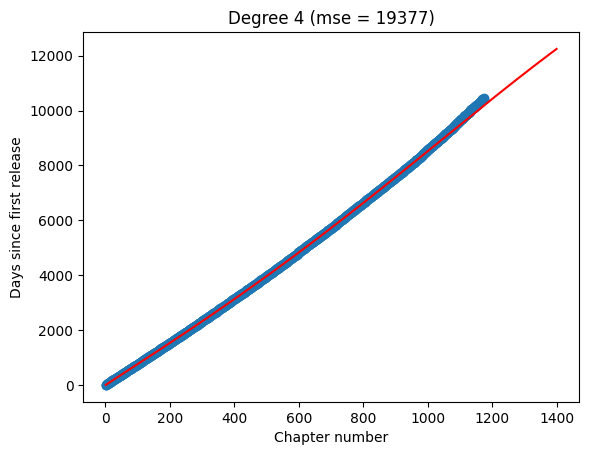

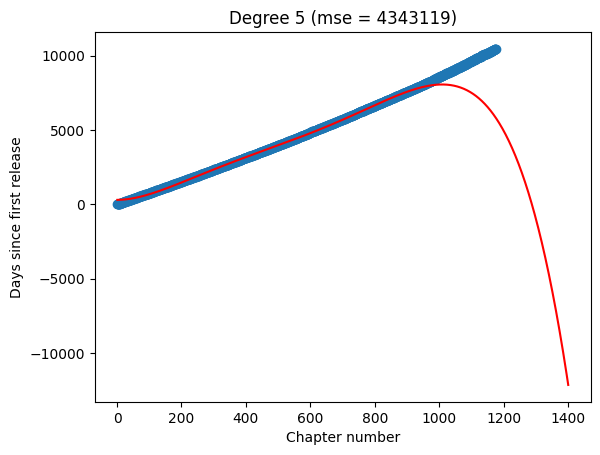

In [42]:
X = df[['chapter']]
y = df['Days since first release']

# Split data into train and test set. 
# shuffle=False to ensure first 80% is past and last 20% is future. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# For plotting predictions until chapter 1400
X_future = np.arange(1,1401).reshape(-1,1) 

for degree in range(1,6):
    # Transform chapter number into their polynomial versions 
    poly_transformer = PolynomialFeatures(degree=degree)
    X_train_poly = poly_transformer.fit_transform(X_train)
    X_test_poly = poly_transformer.transform(X_test)

    # Get a line of best fit on train set
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Predict and evaluate performance on test set
    y_test_pred = model.predict(X_test_poly)
    mse_score = mean_squared_error(y_test, y_test_pred)

    # Make predictions until chapter 1400 to show on graph
    X_future_poly = poly_transformer.fit_transform(X_future)
    y_future_pred = model.predict(X_future_poly)

    # Plot graph
    plt.figure()
    plt.scatter(X, y)
    plt.plot(X_future, y_future_pred, color='r')
    plt.xlabel('Chapter number')
    plt.ylabel('Days since first release')
    plt.title(f'Degree {degree} (mse = {mse_score:.0f})')
    plt.show()